# Torch implementation of the minimax game
Add details here

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch

dtype = torch.float32
np.random.seed(42)
torch.manual_seed(42)
# Paremeters of the exeperiment

SIGMA = torch.tensor([[1.0, 0.5], [0.5, 1.0]], dtype=dtype)
C = torch.tensor([[1.0, 0.5], [0.5, 1.0]], dtype=dtype)

## Agent parametrization

In [74]:
class Agent(nn.Module):
    def __init__(self, d = 2, hidden_dim = 64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, hidden_dim), nn.Tanh(),
                                nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
                                nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
                                nn.Linear(hidden_dim, 1))

    def forward(self, x):
        return self.net(x)


def compute_theta(agent, x):
    x = x.clone().detach().requires_grad_(True)
    phi = agent(x)

    # sum over batch so autograd gives gradient for every sample
    theta = torch.autograd.grad(outputs = phi.sum(), inputs =x,
                                 create_graph=True)[0]
    
    return theta, x


## Nature parametrization

In [75]:
class NatureDrift(nn.Module):
    def __init__(self, C, SIGMA, beta_bound = 10.0):
        super().__init__()
        self.register_buffer("c", C)
        self.register_buffer("Sigma", SIGMA)
        self.register_buffer('sigma_inv', torch.linalg.inv(SIGMA))

        self.raw_beta = nn.Parameter(torch.zeros(1))
        self.beta_bound = beta_bound

    def beta(self):
        return self.beta_bound * torch.tanh(self.raw_beta)
    
    def skew_matrix(self):
        beta = self.beta()
        S = torch.zeros_like(self.c)
        S[0, 1] = beta
        S[1, 0] = -beta
        return S
    
    def B(self):
        S = self.skew_matrix()
        B = (0.5*self.c + S) @ self.sigma_inv
        return B

## Monte-Carlo samples for the loss

In [76]:
def sample_invariant(batch_size, SIGMA, device="cpu", dtype=torch.float32):

    Sigma_np = SIGMA.detach().cpu().numpy()
    d = Sigma_np.shape[0]

    x_np = np.random.multivariate_normal(
        mean=np.zeros(d),
        cov=Sigma_np,
        size=batch_size
    )

    x = torch.tensor(x_np, device=device, dtype=dtype)

    return x

def growth_rate_estimate(agent, nature, batch_size=4096):
    """
    Estimates

    g(alpha, beta)
    =
    E_p[-theta(x)^T B x - 1/2 theta(x)^T c theta(x)]

    where theta(x) = grad phi_alpha(x)
    and x ~ N(0, Sigma).
    """

    SIGMA = nature.Sigma
    C = nature.c
    B = nature.B()

    # Sample x ~ N(0, Sigma)
    x = sample_invariant(
        batch_size,
        SIGMA,
        device=SIGMA.device,
        dtype=SIGMA.dtype
    )

    # Compute theta(x) = grad_x phi(x)
    theta, x = compute_theta(agent, x)

    # Bx, shape (batch_size, d)
    Bx = x @ B.T

    # theta^T Bx, shape (batch_size,)
    drift_term = torch.sum(theta * Bx, dim=1)

    # C theta, shape (batch_size, d)
    Ctheta = theta @ C.T

    # theta^T C theta, shape (batch_size,)
    risk_term = torch.sum(theta * Ctheta, dim=1)

    # integrand for each sample
    integrand = -drift_term - 0.5 * risk_term

    # Monte Carlo average
    return integrand.mean()


nature = NatureDrift(C, SIGMA, beta_bound=10.0)
agent = Agent(d=2, hidden_dim=64)

g_hat = growth_rate_estimate(agent, nature, batch_size=4096)

print(g_hat.item())
print(nature.beta().item())
print(nature.B())

B = nature.B()

print(B @ SIGMA + SIGMA @ B.T)
print(C)

-0.027888743206858635
0.0
tensor([[0.5000, 0.0000],
        [0.0000, 0.5000]], grad_fn=<MmBackward0>)
tensor([[1.0000, 0.5000],
        [0.5000, 1.0000]], grad_fn=<AddBackward0>)
tensor([[1.0000, 0.5000],
        [0.5000, 1.0000]])


## Training loop

In [77]:
agent_optimizer = torch.optim.Adam(agent.parameters(), lr=1e-3)
nature_optimizer = torch.optim.Adam(nature.parameters(), lr=5e-4)

num_epochs = 3000
batch_size = 6000

history = {
    "g": [],
    "beta": []
}

for epoch in range(num_epochs):

    # -------------------------
    # 1. Nature step: minimize g
    # -------------------------
    for p in agent.parameters():
        p.requires_grad_(False)
    for p in nature.parameters():
        p.requires_grad_(True)

    nature_optimizer.zero_grad()

    g_hat = growth_rate_estimate(agent, nature, batch_size=batch_size)
    nature_loss = g_hat

    nature_loss.backward()
    nature_optimizer.step()

    # -------------------------
    # 2. Agent step: maximize g
    # -------------------------
    for p in agent.parameters():
        p.requires_grad_(True)
    for p in nature.parameters():
        p.requires_grad_(False)

    agent_optimizer.zero_grad()

    g_hat = growth_rate_estimate(agent, nature, batch_size=batch_size)
    agent_loss = -g_hat

    agent_loss.backward()
    agent_optimizer.step()

    # -------------------------
    # Logging
    # -------------------------
    if epoch % 100 == 0:
        with torch.no_grad():
            beta_val = nature.beta().item()
            g_val = g_hat.item()

        history["g"].append(g_val)
        history["beta"].append(beta_val)

        print(f"Epoch {epoch:5d} | g_hat = {g_val:.6f} | beta = {beta_val:.4f}")

Epoch     0 | g_hat = -0.028552 | beta = -0.0050
Epoch   100 | g_hat = 0.246945 | beta = -0.0602
Epoch   200 | g_hat = 0.244989 | beta = -0.0342
Epoch   300 | g_hat = 0.244946 | beta = -0.0315
Epoch   400 | g_hat = 0.248232 | beta = -0.0241
Epoch   500 | g_hat = 0.248918 | beta = -0.0342
Epoch   600 | g_hat = 0.250987 | beta = -0.0217
Epoch   700 | g_hat = 0.250046 | beta = -0.0153
Epoch   800 | g_hat = 0.249290 | beta = -0.0131
Epoch   900 | g_hat = 0.256013 | beta = -0.0035
Epoch  1000 | g_hat = 0.244972 | beta = -0.0007
Epoch  1100 | g_hat = 0.254056 | beta = 0.0093
Epoch  1200 | g_hat = 0.251123 | beta = 0.0122
Epoch  1300 | g_hat = 0.249304 | beta = 0.0027
Epoch  1400 | g_hat = 0.251486 | beta = 0.0023
Epoch  1500 | g_hat = 0.247477 | beta = 0.0142
Epoch  1600 | g_hat = 0.251368 | beta = 0.0059
Epoch  1700 | g_hat = 0.249358 | beta = 0.0093
Epoch  1800 | g_hat = 0.254803 | beta = 0.0080
Epoch  1900 | g_hat = 0.251143 | beta = -0.0027
Epoch  2000 | g_hat = 0.246707 | beta = -0.0269

Analytical robust-optimal growth rate: 0.250000
Learned final growth rate estimate:    0.252484
Absolute error:                       0.002484
Learned beta:                         -0.005448


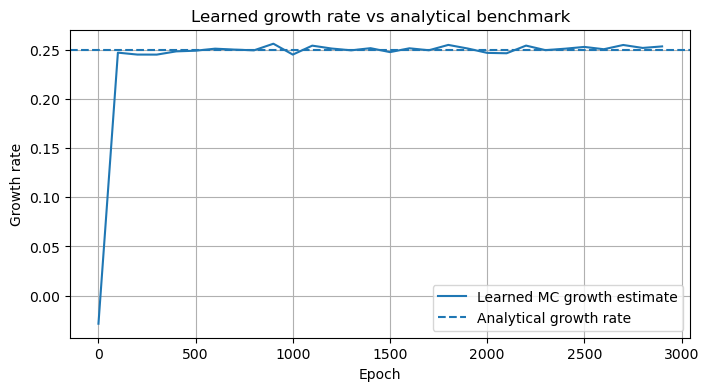

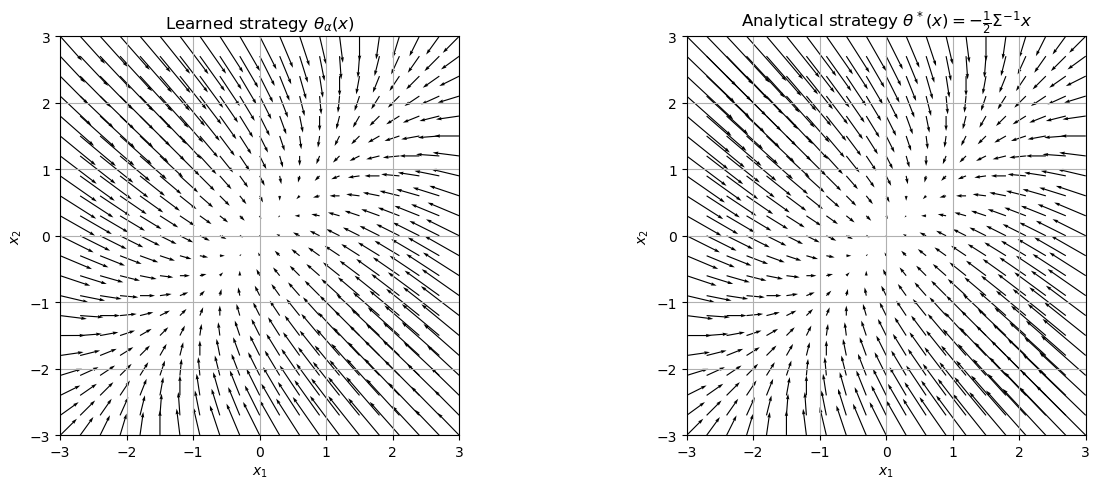

In [78]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# 1. Analytical benchmark
# ============================================================

Sigma = nature.Sigma
C = nature.c
Sigma_inv = torch.linalg.inv(Sigma)

lambda_star = 0.125 * torch.trace(C @ Sigma_inv).item()

# Estimate final learned growth rate with a larger MC batch
g_final = growth_rate_estimate(agent, nature, batch_size=20000).item()

print(f"Analytical robust-optimal growth rate: {lambda_star:.6f}")
print(f"Learned final growth rate estimate:    {g_final:.6f}")
print(f"Absolute error:                       {abs(g_final - lambda_star):.6f}")
print(f"Learned beta:                         {nature.beta().item():.6f}")

# ============================================================
# 2. Plot learned growth rate over training
# ============================================================

g_history = np.array(history["g"])

# If you logged every 100 epochs, this reconstructs the x-axis.
# Change logging_every if you used another print/logging frequency.
logging_every = 100
epochs_logged = logging_every * np.arange(len(g_history))

plt.figure(figsize=(8, 4))
plt.plot(epochs_logged, g_history, label="Learned MC growth estimate")
plt.axhline(lambda_star, linestyle="--", label="Analytical growth rate")
plt.xlabel("Epoch")
plt.ylabel("Growth rate")
plt.title("Learned growth rate vs analytical benchmark")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 3. Helper: compute learned theta on a grid
# ============================================================

def compute_theta_eval(agent, x):
    """
    Computes theta(x) = grad_x phi(x) for evaluation/plotting.

    x shape: (num_points, d)
    output shape: (num_points, d)
    """
    x = x.clone().detach().requires_grad_(True)
    phi = agent(x).sum()

    theta = torch.autograd.grad(
        outputs=phi,
        inputs=x,
        create_graph=False
    )[0]

    return theta.detach()

# ============================================================
# 4. Build grid over [-4, 4]^2
# ============================================================

grid_min, grid_max = -3.0, 3.0
num_grid = 21

x1 = np.linspace(grid_min, grid_max, num_grid)
x2 = np.linspace(grid_min, grid_max, num_grid)

X1, X2 = np.meshgrid(x1, x2)

grid_np = np.column_stack([X1.ravel(), X2.ravel()])
grid = torch.tensor(grid_np, dtype=Sigma.dtype, device=Sigma.device)

# Learned strategy
theta_learned = compute_theta_eval(agent, grid).cpu().numpy()

# Analytical strategy: theta*(x) = -1/2 Sigma^{-1} x
theta_star = (-0.5 * (grid @ Sigma_inv.T)).detach().cpu().numpy()

U_learned = theta_learned[:, 0].reshape(num_grid, num_grid)
V_learned = theta_learned[:, 1].reshape(num_grid, num_grid)

U_star = theta_star[:, 0].reshape(num_grid, num_grid)
V_star = theta_star[:, 1].reshape(num_grid, num_grid)

# ============================================================
# 5. Plot vector fields side by side
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].quiver(X1, X2, U_learned, V_learned, angles="xy", scale_units="xy", scale=4)
axes[0].set_title("Learned strategy $\\theta_\\alpha(x)$")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_xlim(grid_min, grid_max)
axes[0].set_ylim(grid_min, grid_max)
axes[0].set_aspect("equal")
axes[0].grid(True)

axes[1].quiver(X1, X2, U_star, V_star, angles="xy", scale_units="xy", scale=4)
axes[1].set_title(r"Analytical strategy $\theta^*(x)=-\frac{1}{2}\Sigma^{-1}x$")
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")
axes[1].set_xlim(grid_min, grid_max)
axes[1].set_ylim(grid_min, grid_max)
axes[1].set_aspect("equal")
axes[1].grid(True)

plt.tight_layout()
plt.show()